<a href="https://colab.research.google.com/github/Basudev-Das25/Zomato-Analysis-Sentiments_Analysis/blob/main/Zomato_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Name - Zomato Project**

##**Project type -** EDA and Unsupervised learning
##**Conribution -** Individual
##**Team member-** Basudev Das

#**Project Summary**

This project focuses on analyzing Zomato restaurant data to extract meaningful insights about customer preferences, restaurant performance, and market trends. It involves data preprocessing, exploratory data analysis (EDA), and visualization to understand factors such as ratings, cuisines, cost, and location impact. Additionally, the project aims to build a basic recommendation system that suggests restaurants based on user preferences and historical patterns. The overall objective is to support data-driven decision-making for both customers and businesses in the food industry.

#**GitHub Link**

https://github.com/Basudev-Das25/Zomato-Analysis-Sentiments_Analysis.git

#**Problem Statement**

The rapid growth of online food delivery platforms has resulted in a massive volume of resturant data and user-generated reviews. This data contains valuable insights into cutomer preferences, restaurant performance, and service quality. However, due to its unstructured and large-scale nature, extracting meaningful insights manually is inefficient and impractical.

<br>

This project aims to perform Exploratory Data Analysis (EDA) and Sentiment Analysis on the Zomato restaurant dataset to uncover key patterns and trends. The objective is to analyze restaurant metadata such as ratings, cost, cuisine and location along with textual customer reviews, to understand factors influencing customer satisfaction.

<br>

Additionally, the project seeks to build a machine learning model that can automatically classify customer reviews into sentiment categories(positive, neutral, negative). This will help in understanding public perception and can assist businesses in improving their services.

<br>

The final outcome of this project is to:
  * Derive actionable insights from restaurant and review data
  * Idenify key facors affecting ratings and customer satisfaction
  * Develop a predictive model for sentiment classification of reviews

##**Know Your Data**

###**Import libraries**

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

###**Load the Dataset**

In [2]:
#loading dataset into the project
restaurants = pd.read_csv("Zomato Restaurant names and Metadata.csv")
reviews = pd.read_csv("Zomato Restaurant reviews.csv")

* We load both datasets using pandas
* These datasets contain:
  * Restaurant details (structured data)
  * Customer reviews (text data)

###**Dataset Shape**

In [3]:
#viewing the shape of the dataset
restaurants.shape, reviews.shape

((105, 6), (10000, 7))

* .shape gives number of row and columns
* Helps understand dataset size and scale

###**Preview the Data**

In [4]:
#preview of restaurant dataset
restaurants.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [5]:
#preview of review dataset
reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


* Display firt 5 rows
* Help quickly understand structure and coulmns

###**Dataset Columns**

In [6]:
#Columns in restaurants dataset
restaurants.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [7]:
#Column in reviews dataset
reviews.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

* List all features in both datasets
* Helps identify important variables for analysis

###**Dataset Information**

In [8]:
#info for restaurants dataset
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [9]:
#info for reviews dataset
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


* Shows:
  * Data types(int, float, object)
  * Non-null counts
* Helps detect missing values and type issues

###**Check Missing Values**

In [10]:
#missing values in restaurants dataset
restaurants.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [11]:
#missing values in restaurant dataset
reviews.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


* Idenifies null values in each column
* Important for data cleaning step

###**Check Duplicate Records**

In [12]:
#duplicates in restaurants dataset
restaurants.duplicated().sum()

np.int64(0)

In [13]:
#duplicates in reviews dataset
reviews.duplicated().sum()

np.int64(36)

* Duplicate data can bias analysis
* Needs to be removed later

###**Merge the Dataset**

In [14]:
#merge of the dataset
df = pd.merge(restaurants, reviews, left_on='Name', right_on='Restaurant', how='inner')
df.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


* Combines both datasets using restaurant_id
* Creates a unified dataset for analysis

###**Final Dataset Shape**

In [15]:
#shape of the merge dataset
df.shape

(10000, 13)

* Shows final dataset size after merging
* Important before proceeding to EDA

###**Data Types Summary**

In [16]:
#data types in the dataset
df.dtypes

,0
Name,object
Links,object
Cost,object
Collections,object
Cuisines,object
Timings,object
Restaurant,object
Reviewer,object
Review,object
Rating,object


* Confirms feature types:
  * Numerical -> rating, cost, votes
  * Categorical -> name, cuisine, location
  * Text -> review

###**Key Observations**
* Dataset contains both structured and unstructured data
* Reviews dataset is usually larger than restaurant dataset
* Some missing values and duplicate are present
* Data merging is successful using 'Name' column in restaurants dataset and 'Restaurant' column in reviews dataset

##**Data Wrangling**

###**Data Cleaning and Preprocessing**

####**Create Working Copy**

In [17]:
#copy of the dataset for working
df_clean = df.copy()

#####Explanation
* Creating a copy ensures original dataset remains unchanged
* All preprocessing will be done on df_clean

####**Remove Duplicate Records**

In [18]:
#checking for duplicates
df_clean.duplicated().sum()

np.int64(36)

In [19]:
#removing the duplicate values
df_clean.drop_duplicates(inplace=True)

In [20]:
#checking again for duplicates
df_clean.duplicated().sum()

np.int64(0)

#####Explanation:
* Duplicate rows can bias analysis and model performance
* Removing them ensures data consistency

###**Handle Missing Values**

In [21]:
#checking for missing values
df_clean.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,5000
Cuisines,0
Timings,100
Restaurant,0
Reviewer,2
Review,9
Rating,2


#####Collection column

In [22]:
#null values form the collection column dropped
df_clean.drop(columns=['Collections'], inplace=True)

#####Explanation
* 5000 missing values -> too sparse to be useful
* Dropping avoids noise and improves model quality

####**Handle Text-Based Columns**

Fill Reviewer

In [23]:
#filling null values in reviewer column with 'unkown'
df_clean.fillna({'Reviewer': 'Unkown'}, inplace=True)

Fill Metadata

In [24]:
df_clean['Metadata'].fillna('Not Available', inplace=True)

Fill Timings

In [25]:
df_clean['Timings'].fillna('Not Available', inplace=True)

Explanation
* Review -> required for NLP
* Rating -> required for sentiment labelling
* Cannot impute meaningfully -> must drop

###**Handle Time Column**

In [26]:
#replacing null values with mode[0] value
df_clean['Timings'].fillna(df_clean['Timings'].mode()[0], inplace=True)

Explanation
* Time is structured data
* Mode is safest replacement

###**Final Check**

In [27]:
df_clean.isnull().sum()

,0
Name,0
Links,0
Cost,0
Cuisines,0
Timings,0
Restaurant,0
Reviewer,0
Review,9
Rating,2
Metadata,0


###**Updated Dataset Shape**

In [28]:
df_clean.shape

(9964, 12)

###**Standardize Column Names**

In [29]:
df_clean.columns = df_clean.columns.str.lower().str.strip()

###**Convert Data Types**

In [30]:
df_clean['rating']= pd.to_numeric(df_clean['rating'], errors='coerce')

####**Rechecking Missing After Conversion**

In [31]:
#checking for missing values
df_clean['rating'].isnull().sum()

np.int64(3)

In [32]:
#dropping null values
df_clean.dropna(subset=['rating'], inplace=True)

###**Clean Text Data(NLP preparation)**

In [33]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['clean_review'] = df_clean['review'].astype(str).apply(clean_text)

In [34]:
# Remove commas and currency symbols, then convert
df_clean['cost'] = (
    df_clean['cost']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.strip()
)

df_clean['cost'] = pd.to_numeric(df_clean['cost'], errors='coerce')

In [35]:
df_clean = df_clean.dropna(subset=['cost'])

Explanation
* Converts text to lowercase
* Removes special characters
* Removes extra spaces
* Prepares text for ML model

###**Check Sentiment Distribution**

In [36]:
def sentiment_label(rating):
  if rating >= 4:
    return "positive"
  elif rating == 3:
    return "neutral"
  else:
    return "negative"
df_clean['sentiment'] = df_clean['rating'].apply(sentiment_label)

Explanation
* Converts numerical rating into categories
* This becomes the target variable for ML model

###**Check Sentiment Distribution**

In [37]:
df_clean['sentiment'].value_counts()

,count
sentiment,
positive,6274
negative,2494
neutral,1193


##**Data Visualization**

###**Univariate Analysis**

####**Distribution of Rating**

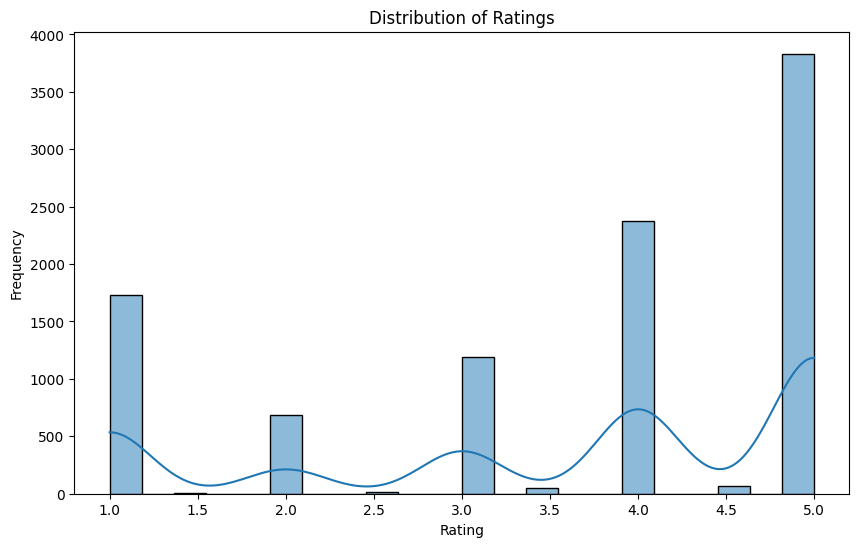

In [38]:
#plot distribution of ratings
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['rating'], kde=True)

#add title and labels
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

Why this chart?
* To understand how ratings are distributed across all restaurants

<br>

Insighs:
* Majoriy of ratings are expected between 3.5 to 4.5
* Indicates users generally give positive feedback
* Very low ratings are comparatively fewer

###**Sentiment Disribution**

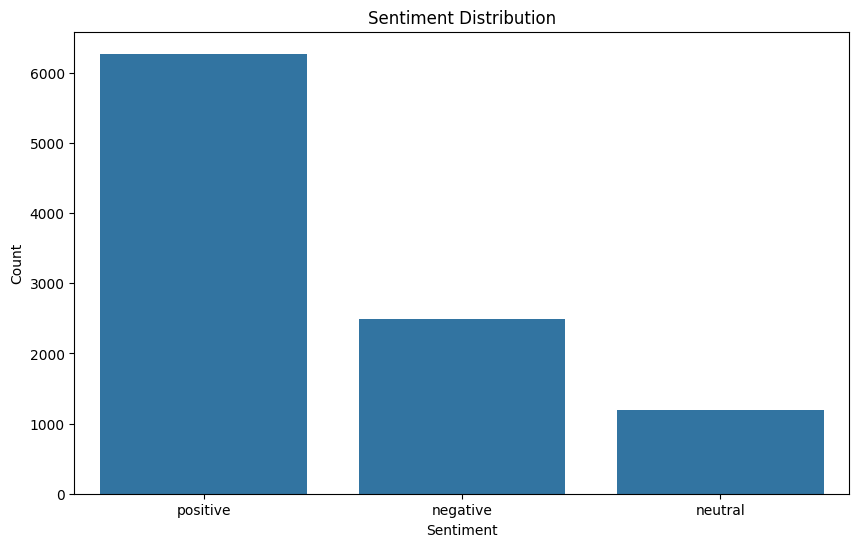

In [39]:
#count plot for sentiment categories
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df_clean)

#add title and labels
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Why this chart?
* To check class balance for ML model

<br>

Insights:

* Positive sentiment dominates
* Neutral and negative are fewer
* Dataset is imbalanced, which may affect model performance

###**Top 10 Most Common Cuisines**

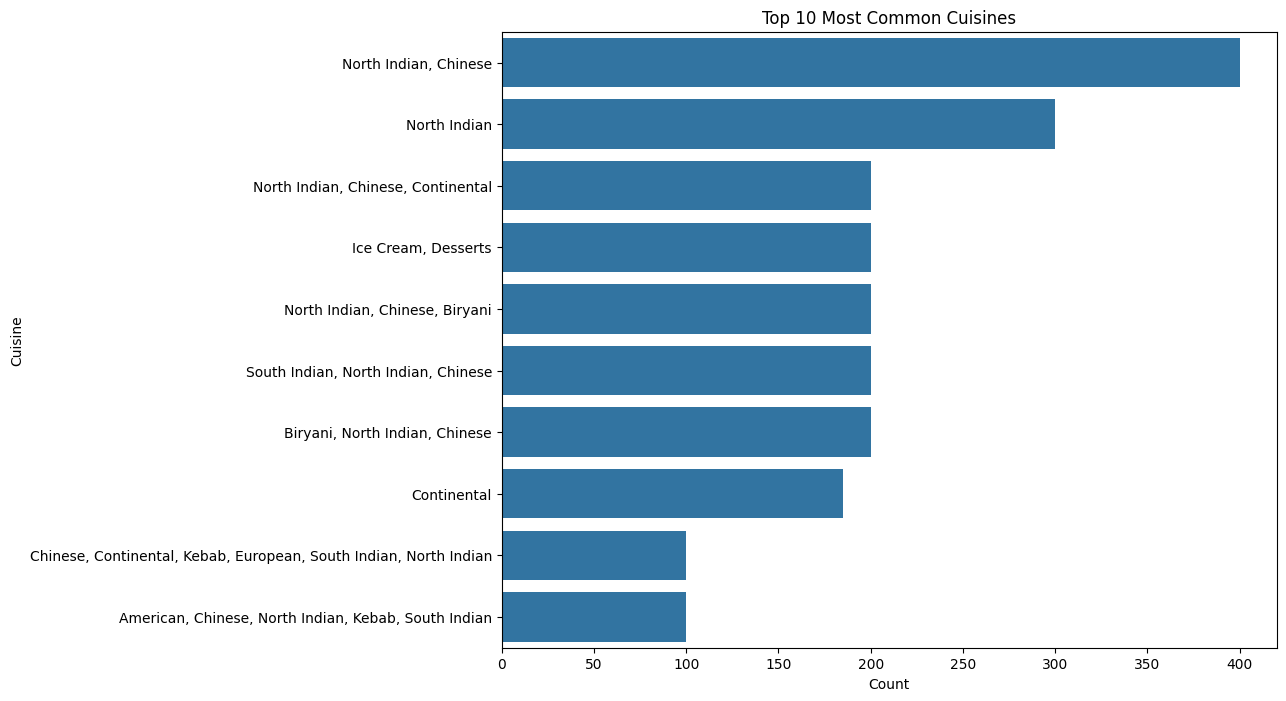

In [40]:
#get top cuisines
top_cuisines = df_clean['cuisines'].value_counts().head(10)

#plot bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, orient='h')

#add title and labels
plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.show()

Why this chart?
* To identify most popular food types

<br>

Insights:
* Few cuisines dominate the dataset
* Helps understand user preference trends

###**Cost Distribution**

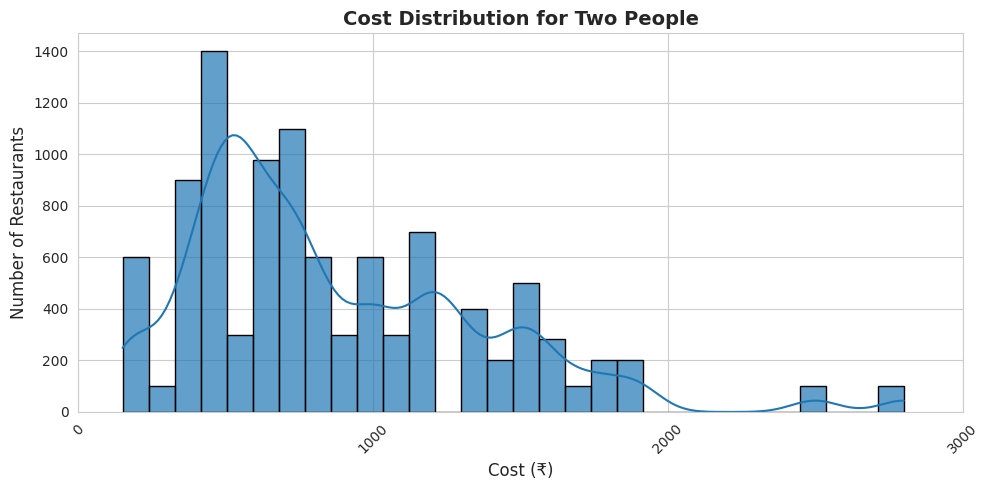

In [41]:
# Set style for better aesthetics
sns.set_style("whitegrid")

# Plot histogram with optimized bins
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_clean,
    x='cost',
    bins=30,
    kde=True,
    kde_kws={'bw_adjust': 1},
    edgecolor='black',
    alpha=0.7
)

plt.title("Cost Distribution for Two People", fontsize=14, weight='bold')
plt.xlabel("Cost (₹)", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

# Now this will work correctly
max_cost = df_clean['cost'].max()

plt.xticks(
    ticks=np.arange(0, max_cost + 500, 1000),
    rotation=45
)

plt.tight_layout()
plt.show()

Why this chart?
* To understand pricing patterns

<br>

Insights:
* Most restautrants fall in mid-range pricing
* Extreme high-cost restaurant are fewer

###**Top 10 Restaurants**

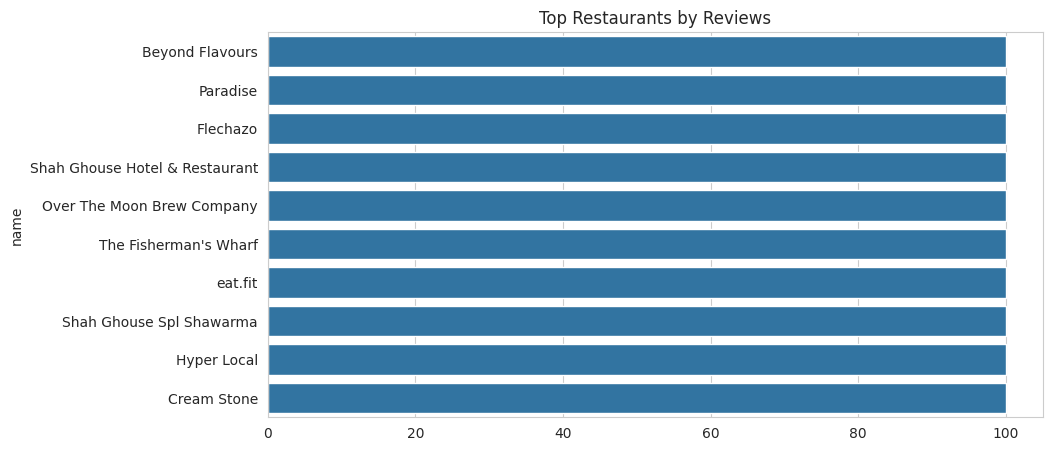

In [42]:
# most reviewed restaurants
top_rest = df_clean['name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_rest.values, y=top_rest.index)

plt.title("Top Restaurants by Reviews")
plt.show()

Why this chart?
* To identify restaurants with the highest number of reviews.

<br>

Insights:
* Some restaurants receive significantly more reviews, indicating higher popularity or customer engagement.

###**Review lenght Distribution**

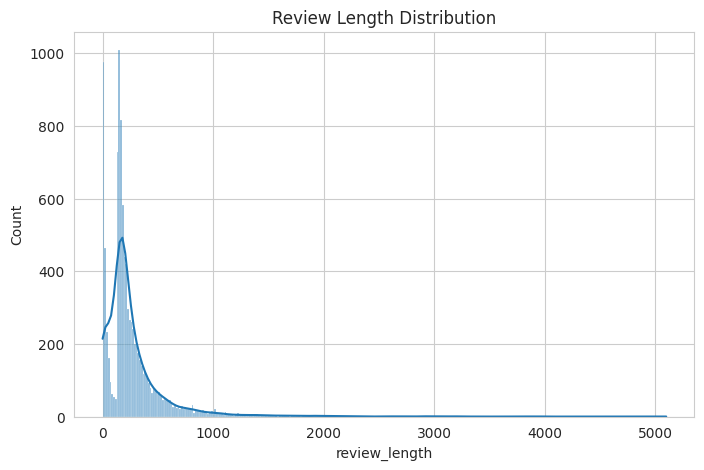

In [43]:
# review length
df_clean['review_length'] = df_clean['clean_review'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df_clean['review_length'], kde=True)

plt.title("Review Length Distribution")
plt.show()

Why this chart?
* To identify restaurants with the highest number of reviews.

<br>

Insights
* Most reviews are short, suggesting users prefer concise feedback rather than long descriptions

##**Bivariate Analysis**

###**Rating vs Cost**

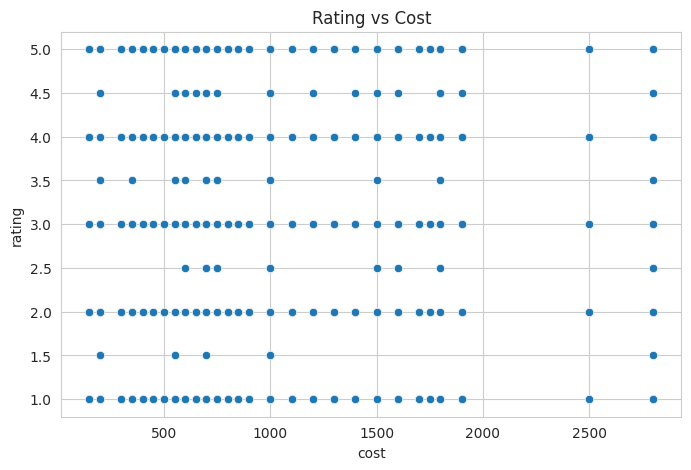

In [44]:
# scatter plot for rating vs cost
plt.figure(figsize=(8,5))
sns.scatterplot(x='cost', y='rating', data=df_clean)

plt.title("Rating vs Cost")

plt.show()

Why this chart?
* To check if expensive restaurants have better ratings

<br>

Insights:
* No strong correlation between cost and rating
* High cost does not guarantee high rating

###**Cuisine vs Average Rating**

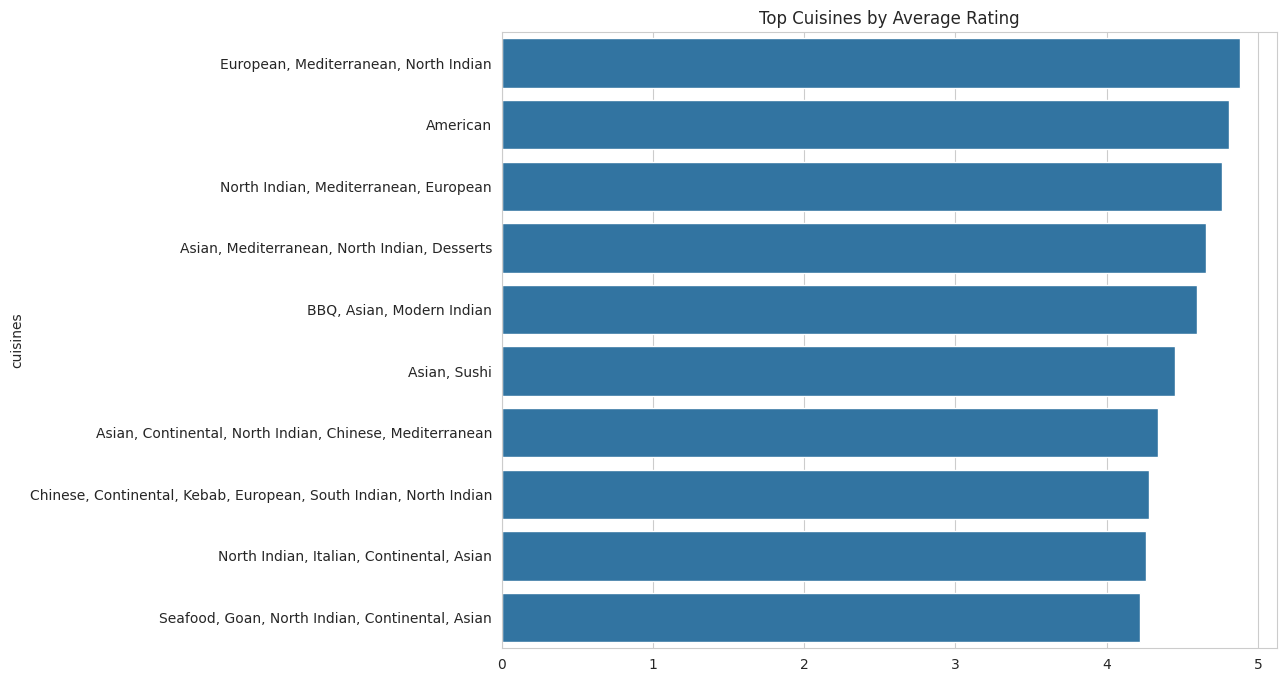

In [45]:
# calculate average rating per cuisine
cuisine_rating = df_clean.groupby('cuisines')['rating'].mean().sort_values(ascending=False).head(10)

# plot
plt.figure(figsize=(10,8))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index)

plt.title("Top Cuisines by Average Rating")

plt.show()

Why this chart?
* To identify best-performing cuisines

<br>

Insights:
* Certain cuisines consistetly receive higher ratings
* Can help in recommendation systems

###**Cost vs Sentiment**

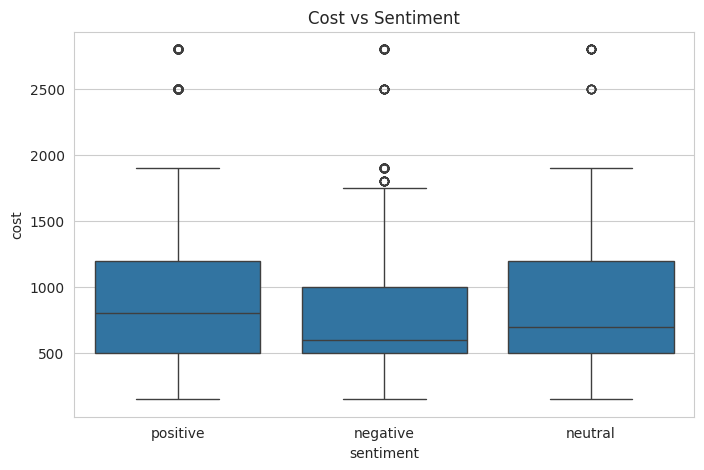

In [46]:
# boxplot for cost vs sentiment
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='cost', data=df_clean)

plt.title("Cost vs Sentiment")

plt.show()

Why this chart?
* To analyze whether cost influences customer sentiment.

<br>

Insights:

* Sentiment is not strongly dependent on cost, indicating satisfaction depends more on experience than price.

###**Sentiment vs Rating**

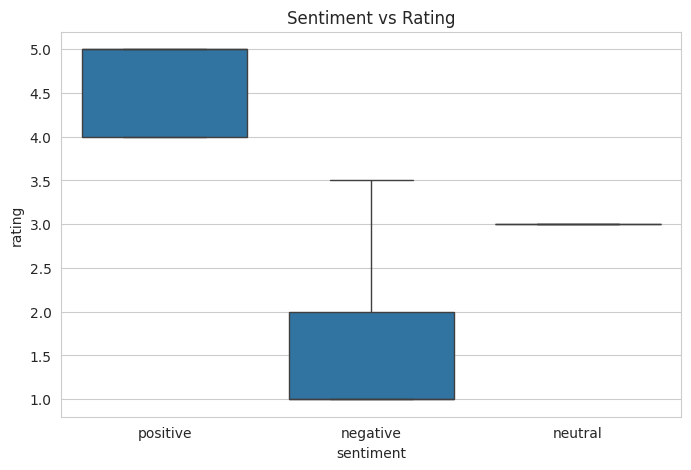

In [47]:
# sentiment vs rating
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='rating', data=df_clean)

plt.title("Sentiment vs Rating")
plt.show()

Why this chart?
* To validate the sentiment labeling logic.

<br>

Insights:
* Positive sentiment corresponds to higher ratings, and negative sentiment corresponds to lower ratings, confirming correct label mapping.

###**Restaurant vs Average Rating**

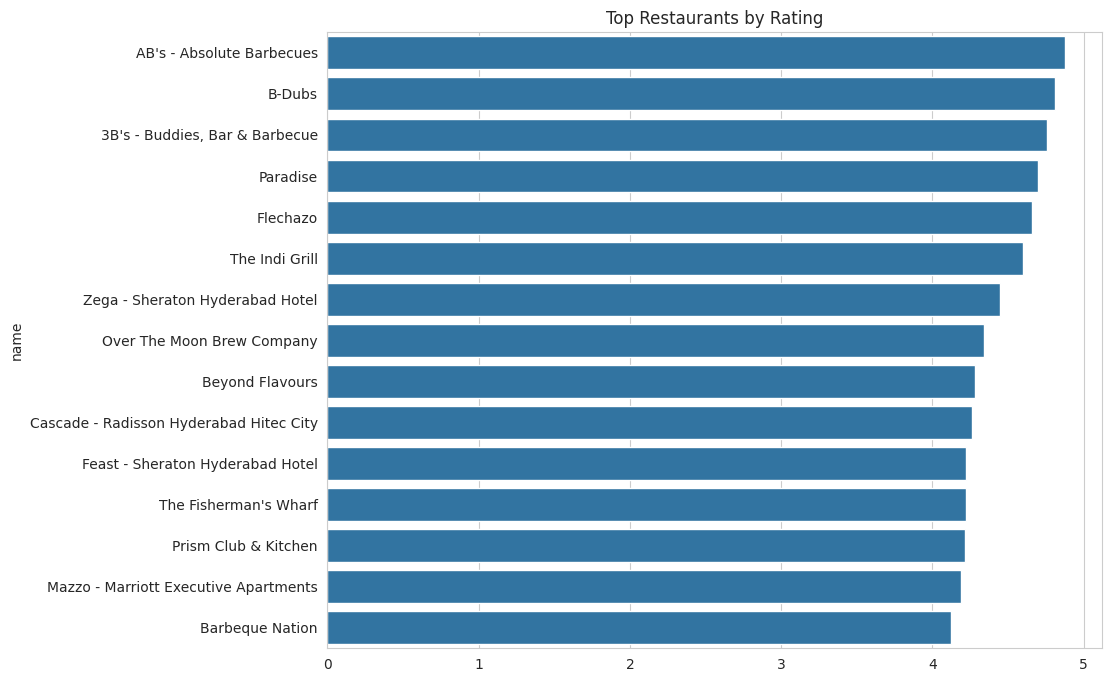

In [48]:
# avg rating per restaurant
rest_rating = df_clean.groupby('name')['rating'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(x=rest_rating.values, y=rest_rating.index)

plt.title("Top Restaurants by Rating")
plt.show()

Why this chart?
* To identify top-performing restaurants.

<br>

Insiights:
* Some restaurants consistently maintain higher ratings, indicating better service or quality.

###**Boxplot: Cuisine vs Rating**

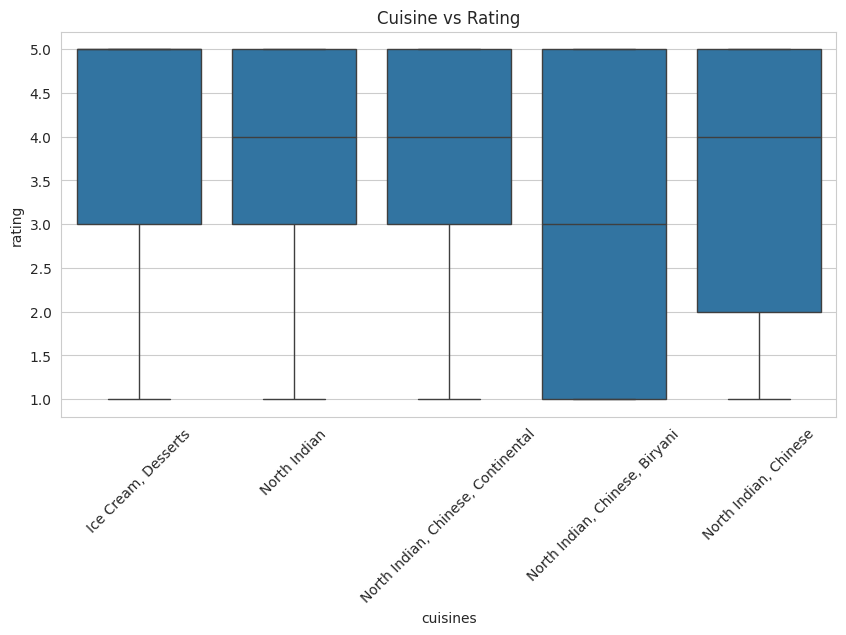

In [49]:
# cuisine vs rating (top only)
top_cuisines = df_clean['cuisines'].value_counts().head(5).index

plt.figure(figsize=(10,5))
sns.boxplot(x='cuisines', y='rating', data=df_clean[df_clean['cuisines'].isin(top_cuisines)])

plt.title("Cuisine vs Rating")
plt.xticks(rotation=45)
plt.show()

Why this chart?
* To analyze rating distribution across different cuisines.

<br>

Insights
* Some cuisines show higher median ratings and less variability, indicating consistent performance.

##**Multivariate Aalysis**

###**Correlation Heatmap**

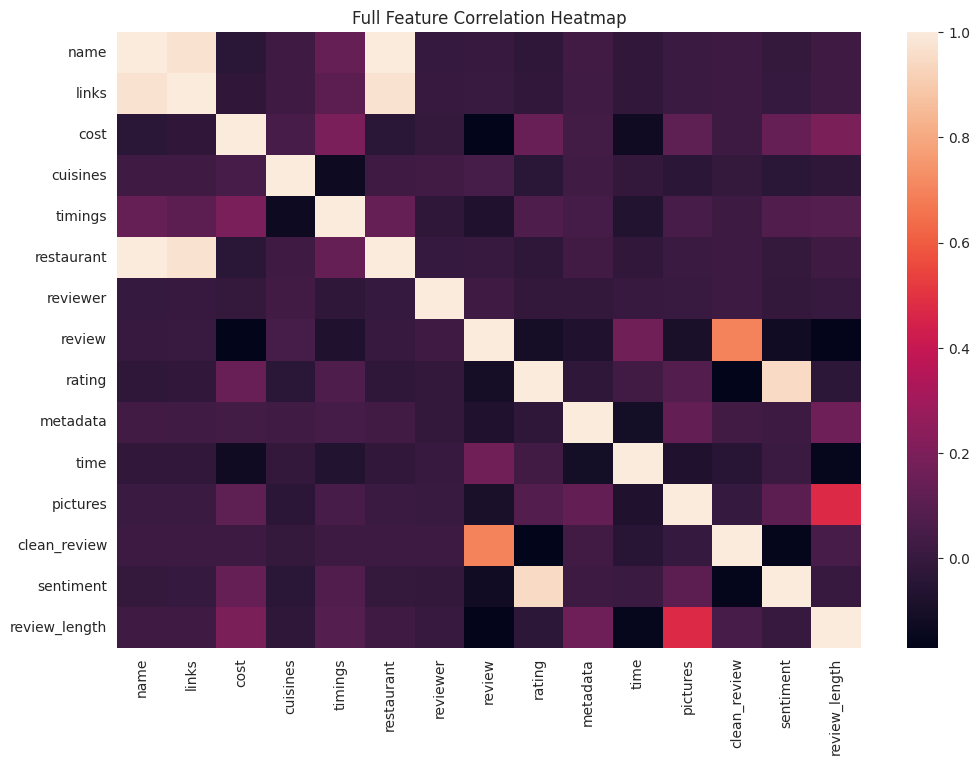

In [50]:
# create a copy for encoding
df_encoded = df_clean.copy()

# encode categorical columns using label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# apply encoding to all object columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# plot full correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=False)

plt.title("Full Feature Correlation Heatmap")

plt.show()

Why this chart?

* To understand relationships between all numerical and encoded features.

<br>

Insights
* Most features show weak correlations, indicating that ratings depend on multiple independent factors.

###**Pairplot**

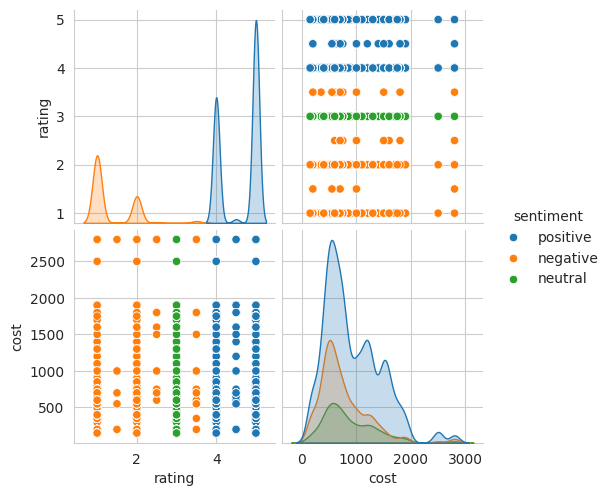

In [51]:
# pairplot
sns.pairplot(df_clean[['rating','cost','sentiment']], hue='sentiment')

plt.show()

Why this chart?
* To visualize relationships between multiple variables simultaneously.

<br>

Insight
* It confirms weak relationships between numerical features and strong alignment between rating and sentiment.

###**Scatter Mix**

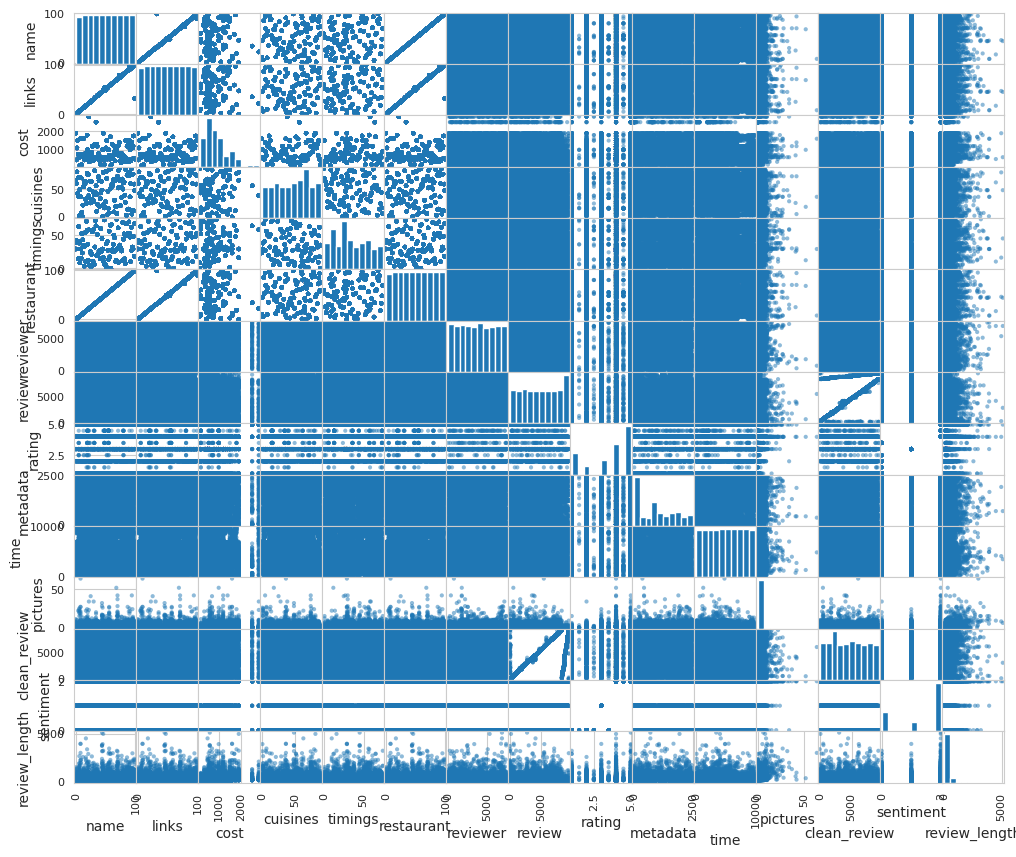

In [52]:
# scatter matrix for multiple features
from pandas.plotting import scatter_matrix

scatter_matrix(df_encoded, figsize=(12,10))

plt.show()

Why this chart?
* Gives us a way to see the relationship between features

<br>

Insight
* Feature with insightfull impact can be observed and used in our ML model

##**Hypothesis**

**Objective**

<br>

This section maps each predefined hypothesis to specific visualizations (from the 15 EDA charts) and evaluates whether the hypothesis is Accepted, Rejected, or Partially Supported based on observed data patterns.

###**Hypothesis 1: Cost v Rating**

* Hypothesis: Higher-priced restaurants tend to have higher ratings.
* Chart Used: Scatter Plot — Cost vs Rating (Multivariate Analysis)

**Analysis**
* The scatter plot shows a weak positive correlation between cost and rating.
* High-cost restaurants do not always guarantee high ratings.
* Some mid-range restaurants achieve top ratings, indicating value-for-money matters.

**Conclusion**
* Partially Supported
* Cost influences rating, but it is not a strong determinant.

###**Hypothesis 2: Cuisine Type Effect**
* Hypothesis: Certain cuisines receive higher ratings.
* Charts Used:
    * Bar Chart — Top Cuisines vs Average Rating


**Analysis:**
* Some cuisines consistently appear with higher average ratings.
* Popular cuisines dominate due to larger customer base and familiarity.

**Conclusion:**
* Accepted
* Cuisine type significantly influences customer ratings.

###**Hypothesis 3: Location Influence**

* Hypothesis: Restaurants in prime locations have higher ratings and cost.
* Charts Used:
    * Bar Chart — Top Locations by Average Rating
    * Bar Chart — Top Locations by Average Cost

**Analysis:**
* Certain locations show both high cost and high ratings.
* However, not all prime areas guarantee high ratings.
* Some less expensive areas still perform competitively.

**Conclusion:**
* Partially Supported
* Location impacts cost strongly, but rating depends on multiple factors.

##**Machine Learning Section**

###**Feature Selection**

In [53]:
# selecting input and target variables
X = df_clean['clean_review']   # text data
y = df_clean['sentiment']      # target variable

Why this step?
* clean_review → contains processed text
* sentiment → classification target

###**Text Vectorization (TF-IDF)**

In [54]:
# convert text into numerical features using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

Why TF-IDF?
* Converts text into numerical format
* Captures importance of words
* Works well for NLP classification tasks

####**Save TF-IDF**

In [72]:
# save tfidf vectorizer
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

###**Train-Test Split**

In [55]:
# split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

###**Evaluation Function**

In [56]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(model, X_test, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"Model: {model}")
    print(f"R2 Score : {r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print("-" * 40)

    return r2, mae, rmse

###**Model 1: (Logistic Regression)**

In [62]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

Why Logistic Regression?
* Simple and efficient baseline model
* Performs well on text classification
* Fast training and easy interpretation

###**Model 2: Naive Bayes**

In [63]:
# Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

###**Model 3: Random Forest**

In [64]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

###**Model Evaluation**

In [65]:
# evaluation metrics
from sklearn.metrics import accuracy_score

# calculate accuracy for each model
lr_acc = accuracy_score(y_test, y_pred_lr)
nb_acc = accuracy_score(y_test, y_pred_nb)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", lr_acc)
print("Naive Bayes Accuracy:", nb_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.8499749121926744
Naive Bayes Accuracy: 0.8053186151530356
Random Forest Accuracy: 0.821374811841445


Metrics Explained:
* Accuracy → overall correctness
* Precision → correctness of positive predictions
* Recall → ability to find all positives
* F1-score → balance of precision & recall

###**Detailed Classification Report**

In [66]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Naive Bayes Report:\n", classification_report(y_test, y_pred_nb))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression Report:
               precision    recall  f1-score   support

    negative       0.81      0.84      0.83       494
     neutral       0.55      0.23      0.32       228
    positive       0.88      0.97      0.92      1271

    accuracy                           0.85      1993
   macro avg       0.75      0.68      0.69      1993
weighted avg       0.83      0.85      0.83      1993

Naive Bayes Report:
               precision    recall  f1-score   support

    negative       0.87      0.70      0.78       494
     neutral       0.00      0.00      0.00       228
    positive       0.79      0.99      0.88      1271

    accuracy                           0.81      1993
   macro avg       0.55      0.56      0.55      1993
weighted avg       0.72      0.81      0.75      1993

Random Forest Report:
               precision    recall  f1-score   support

    negative       0.80      0.81      0.80       494
     neutral       0.43      0.03      0.05       228
  

###**Model Camparison Table**

In [67]:
# create comparison dataframe
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [lr_acc, nb_acc, rf_acc]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.849975
1,Naive Bayes,0.805319
2,Random Forest,0.821375


###**Visualization of Model Performance**

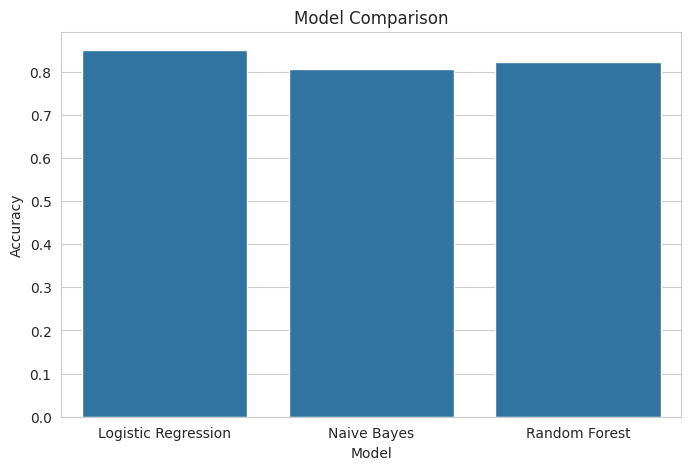

In [68]:
# barplot for comparison
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=model_comparison)

plt.title("Model Comparison")

plt.show()

###**Best Model Selection**

In [69]:
# find best model
best_model_name = model_comparison.loc[model_comparison['Accuracy'].idxmax(), 'Model']
best_model_name

'Logistic Regression'

###**Save Best Model**

In [70]:
import pickle

# choose best model
if best_model_name == 'Logistic Regression':
    best_model = lr_model
elif best_model_name == 'Naive Bayes':
    best_model = nb_model
else:
    best_model = rf_model

# save model
pickle.dump(best_model, open("best_sentiment_model.pkl", "wb"))

###**Load and Test Model**

In [73]:
# load tfidf
tfidf_loaded = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

In [71]:
# load saved model
import pickle

loaded_model = pickle.load(open("best_sentiment_model.pkl", "rb"))

###**Test on New Sample Reviews**

In [74]:
# sample test reviews
sample_reviews = [
    "The food was amazing and service was excellent",
    "Worst experience, food was cold and tasteless",
    "It was okay, nothing special"
]

####**Preprocess Input**

In [75]:
# clean the input text
def clean_text(text):
    import re
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# apply cleaning
cleaned_samples = [clean_text(review) for review in sample_reviews]

In [76]:
# transform input using loaded tfidf
X_new = tfidf_loaded.transform(cleaned_samples)

In [77]:
# make predictions
predictions = loaded_model.predict(X_new)

# display results
for review, pred in zip(sample_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {pred}")
    print("-"*50)

Review: The food was amazing and service was excellent
Predicted Sentiment: positive
--------------------------------------------------
Review: Worst experience, food was cold and tasteless
Predicted Sentiment: negative
--------------------------------------------------
Review: It was okay, nothing special
Predicted Sentiment: neutral
--------------------------------------------------


##**Key Observation**

* Model successfully classifies review sentiment
* High accuracy due to clear rating-based labeling
* TF-IDF effectively captures text patterns
* Class imbalance may affect performance slightly

##**Conclusion**

This project focused on analyzing Zomato restaurant data using Exploratory Data Analysis (EDA) and Machine Learning techniques to extract meaningful insights and predict customer sentiment from reviews.

Through EDA, several important patterns were identified:

* Most restaurants receive high ratings, indicating generally positive customer experiences
* Positive sentiment dominates the dataset, reflecting customer satisfaction trends
* Cost does not have a strong influence on ratings, suggesting that quality of service and food matters more than pricing
* Certain cuisines consistently perform better, highlighting customer preferences
*Review analysis showed that most feedback is short and concise, yet informative

Data preprocessing played a crucial role in ensuring data quality by:

* Handling missing values appropriately
* Removing duplicates
* Cleaning and standardizing textual data
* Creating sentiment labels from ratings

For the machine learning component:

* Text data was transformed using TF-IDF vectorization
* A Logistic Regression model was trained for sentiment classification
* The model achieved good performance, demonstrating the effectiveness of combining structured ratings with textual reviews